In [8]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import mean_absolute_percentage_error, median_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
# Lire le fichier execl
df = pd.read_excel('Zillow.com House Price Prediction Data.xlsx')

# Demension de BD
print("Shape initial :", df.shape)

# Suppression des colonnes avec des valeurs null > 50%
colonnes_supprimees = []
for col in df.columns:
    if df[col].isna().sum() * 100 / len(df) > 50:
        df = df.drop(columns=col)
        colonnes_supprimees.append(col)
print("Colonnes supprimées (>50% NA) :", colonnes_supprimees)

# Suppression les colonnes qui ont des valeurs unique
for col in df.columns:
    if df[col].nunique() == 1:
        df = df.drop(columns=col)

# Suppression des valeurs complexs
drop_columns = ['contact_recipients','imgSrc','taxHistory','listed_by','nearbyHomes',
                'description','priceHistory','schools','address','attributionInfo',
                'resoFacts','listingSubType','url','listingProvider','mortgageZHLRates',
                'mortgageRates','zestimateHighPercent','favoriteCount']
df = df.drop(columns=[c for c in drop_columns if c in df.columns])

# Suppression des colonnes ayant des valeurs dominantes
for col in df.columns:
    freq = df[col].value_counts() * 100 / len(df)
    if freq.values[0] > 90:
        df = df.drop(columns=col)

# Suppression des valeurs initules
drop_columns2 = ['state','county','timeZone','countyId','city','propertyTypeDimension','zpid',
                 'stateId','countyFIPS','zipcode','streetAddress','latitude','longitude',
                 'timeOnZillow','pageViewCount','rentZestimate','zestimate','zestimateLowPercent','annualHomeownersInsurance']
df = df.drop(columns=[c for c in drop_columns2 if c in df.columns])

# filtrer les lignes ayant des données manquantes > 70% 
prop_vides = (df.isna() | (df == 0)).sum(axis=1) / df.shape[1]
df = df[prop_vides < 0.7]

# filtrer df
df = df[df['price'] > 1000]

# Suppression les outliers
# Suppression des outliers avec un masque cumulé
variable_continue = ['livingAreaValue', 'price']
mask = pd.Series(True, index=df.index)

for col in variable_continue:
    if col in df.columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        mask &= (df[col] >= lower) & (df[col] <= upper)

df = df[mask]

# Implémentation des valeurs null par médian
cols_numeriques = df.select_dtypes(include=['int64', 'float64']).columns
for col in cols_numeriques:
    if df[col].isna().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

# Implémentation des valeurs null par mode
cols_categorielles = df.select_dtypes(include=['object', 'category']).columns
for col in cols_categorielles:
    if df[col].isna().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

# One-Hot encoding
df = pd.get_dummies(df, columns=cols_categorielles, drop_first=True)

# Visuler shape après prétraitement
print("Shape après le prétrétement : ",df.shape)

# Réinitialiser les index
df = df.reset_index(drop=True)

Shape initial : (7160, 67)
Colonnes supprimées (>50% NA) : ['monthlyHoaFee', 'dateSold', 'brokerageName', 'providerListingID', 'brokerId', 'comingSoonOnMarketDate', 'building', 'homeFacts', 'datePosted', 'isListedByOwner', 'mlsid', 'buildingId', 'solarPotential', 'contingentListingType', 'message', 'resoFacts.daysOnZillow']
Shape après le prétrétement :  (4835, 15)


C:\Users\floul\AppData\Local\Temp\ipykernel_24748\3649604444.py:69: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cols_categorielles = df.select_dtypes(include=['object', 'category']).columns


In [10]:

# Variables explicatives
X = df.drop('price', axis=1)

# Varaibles cibles
y = df['price']

# Division des données
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=100)

# Standardisation 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Vérifier les valeurs nulles après  Standardisation 
print("NaN dans X_train_scaled :", np.isnan(X_train_scaled).sum())
print("NaN dans X_test_scaled :", np.isnan(X_test_scaled).sum())


NaN dans X_train_scaled : 0
NaN dans X_test_scaled : 0


In [11]:

#
def entrainer(xtrain , xtest , ytrain , ytest):
  models = {
    'Linear Regression': LinearRegression(),
    'SVR': SVR(kernel='rbf', C=1.0, epsilon=0.1),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=100),
    'XGBoost': XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=100, verbosity=0)
}
  results = []
  for name, model in models.items():
    model.fit(xtrain, ytrain)
    ypred = model.predict(xtest)

    rmse = np.sqrt(mean_squared_error(ytest, ypred))
    mae = mean_absolute_error(ytest, ypred)
    r2 = r2_score(ytest, ypred)
    mape = mean_absolute_percentage_error(ytest, ypred)
    medae = median_absolute_error(ytest, ypred)

    results.append({'Modèle': name, 'RMSE': rmse, 'MAE': mae,'R²': r2, 'MAPE': mape, 'MedAE': medae})

  return pd.DataFrame(results)

df_results_scaled = entrainer(X_train_scaled, X_test_scaled, y_train, y_test)
df_results_no_scaled = entrainer(X_train, X_test, y_train, y_test)

# Affichge des métrique avec Standaridation
print("Tableau comparatif avec Standaridation :")
print(df_results_scaled.round(4))
print('\n')

# Affichge des métrique sans Standaridation
print("Tableau comparatif sans Standaridation :")
print(df_results_no_scaled.round(4))


Tableau comparatif avec Standaridation :
              Modèle         RMSE          MAE      R²    MAPE       MedAE
0  Linear Regression   73268.7209   45497.2040  0.6828  0.1431  30601.6944
1                SVR  129853.4586  103049.5068  0.0036  0.3822  83636.6344
2      Random Forest   64796.2945   42627.3052  0.7519  0.1286  26677.0786
3            XGBoost   62218.3057   41392.8242  0.7712  0.1297  26224.9375


Tableau comparatif sans Standaridation :
              Modèle         RMSE          MAE      R²    MAPE       MedAE
0  Linear Regression   73268.7209   45497.2040  0.6828  0.1431  30601.6944
1                SVR  130146.4208  103318.8650 -0.0009  0.3832  83893.6224
2      Random Forest   65125.3039   42762.1137  0.7494  0.1293  27028.0000
3            XGBoost   62218.3057   41392.8242  0.7712  0.1297  26224.9375


C:\Users\floul\AppData\Local\Temp\ipykernel_24748\2639914321.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_results_scaled, x='Modèle', y='RMSE', palette='viridis')


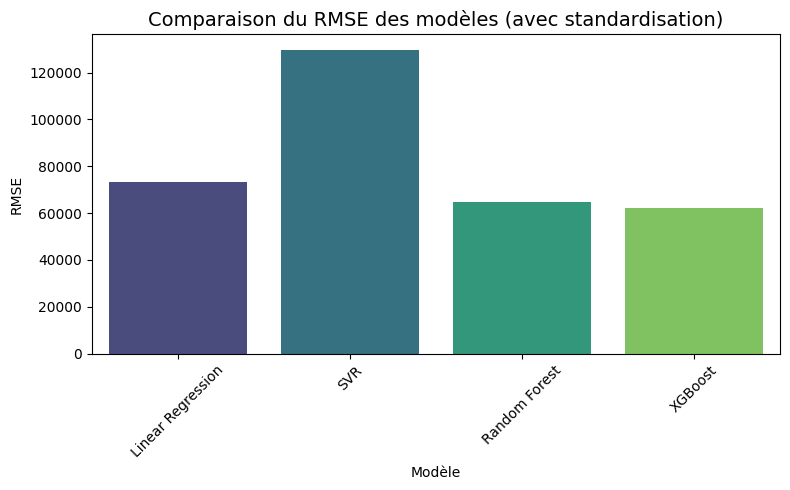

C:\Users\floul\AppData\Local\Temp\ipykernel_24748\2639914321.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_results_scaled, x='Modèle', y='R²', palette='plasma')


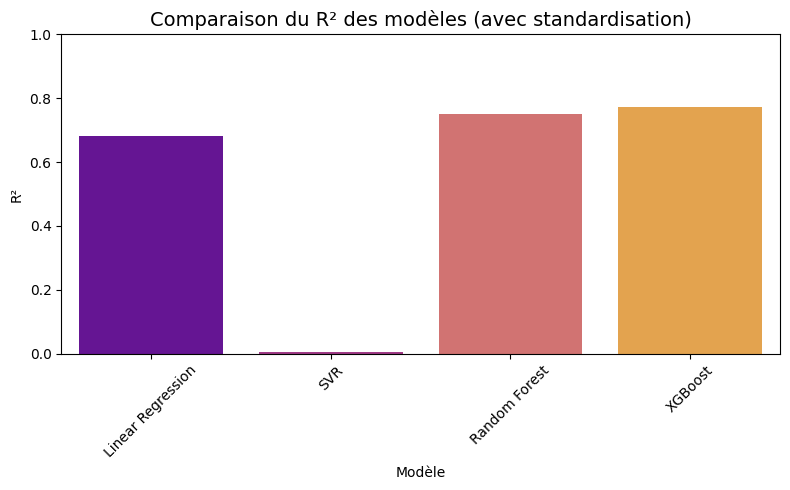

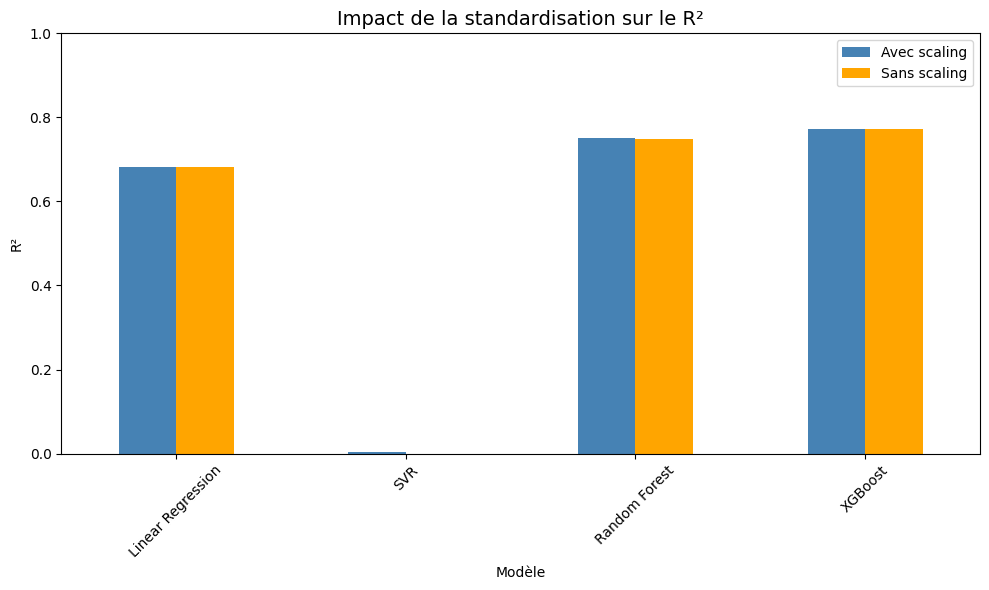

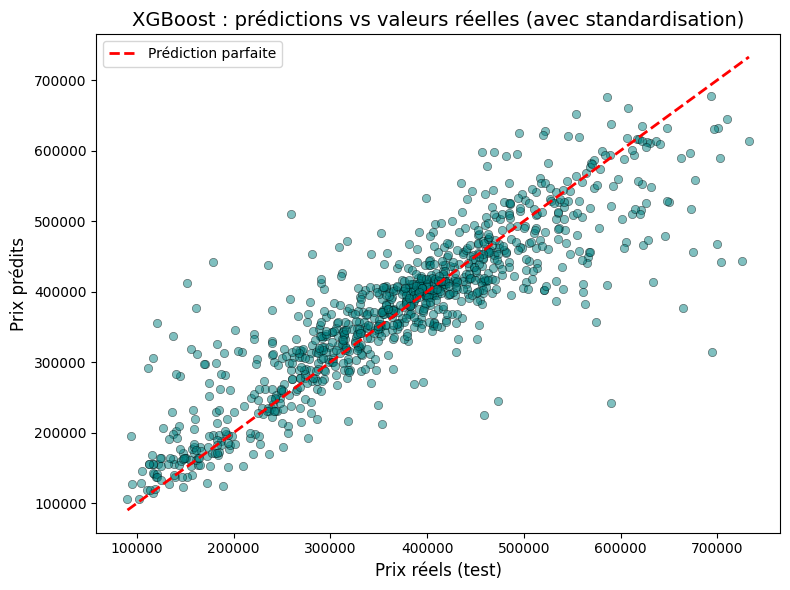

In [12]:




# Graphique 1 : RMSE (avec scaling)

plt.figure(figsize=(8,5))
sns.barplot(data=df_results_scaled, x='Modèle', y='RMSE', palette='viridis')
plt.title('Comparaison du RMSE des modèles (avec standardisation)', fontsize=14)
plt.xlabel('Modèle')
plt.ylabel('RMSE')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Graphique 2 : R² (avec scaling)

plt.figure(figsize=(8,5))
sns.barplot(data=df_results_scaled, x='Modèle', y='R²', palette='plasma')
plt.title('Comparaison du R² des modèles (avec standardisation)', fontsize=14)
plt.xlabel('Modèle')
plt.ylabel('R²')
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Graphique 3 : Impact du scaling sur le R²

comparaison_r2 = pd.DataFrame({
    'Modèle': df_results_scaled['Modèle'],
    'Avec scaling': df_results_scaled['R²'],
    'Sans scaling': df_results_no_scaled['R²']
})
plt.figure(figsize=(10,6))
comparaison_r2.plot(x='Modèle', kind='bar', color=['steelblue', 'orange'], ax=plt.gca())
plt.title('Impact de la standardisation sur le R²', fontsize=14)
plt.ylabel('R²')
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# Graphique 4 : Nuage de points XGBoost

best_model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=100, verbosity=0)
best_model.fit(X_train_scaled, y_train)
y_pred_best = best_model.predict(X_test_scaled)

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_best, alpha=0.5, color='teal', edgecolors='k', linewidth=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2, label='Prédiction parfaite')
plt.xlabel('Prix réels (test)', fontsize=12)
plt.ylabel('Prix prédits', fontsize=12)
plt.title('XGBoost : prédictions vs valeurs réelles (avec standardisation)', fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()